In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/Banking dataset.csv')

In [70]:
print(df.isnull().sum())

Row_Number                 0
Customer_Id                0
Surname                    0
Credit_Score               0
Geography                456
Gender                   453
Age                        0
Tenure                     0
Balance                  550
Num_Of_Products            0
Has_Cr_Card                0
Is_Active_Member           0
Estimated_Salary         455
Exited                     0
Join_Date                  0
Last_Transaction_Date      0
Account_Type               0
dtype: int64


In [71]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])

df['Balance'] = df['Balance'].fillna(df['Balance'].median())
df['Estimated_Salary'] = df['Estimated_Salary'].fillna(df['Estimated_Salary'].median())


print(df.isnull().sum())

Row_Number               0
Customer_Id              0
Surname                  0
Credit_Score             0
Geography                0
Gender                   0
Age                      0
Tenure                   0
Balance                  0
Num_Of_Products          0
Has_Cr_Card              0
Is_Active_Member         0
Estimated_Salary         0
Exited                   0
Join_Date                0
Last_Transaction_Date    0
Account_Type             0
dtype: int64


In [ ]:
df = df.drop_duplicates()

print("duplicated rows :",df.duplicated().sum())



duplicated rows : 0


In [73]:
df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany', 'Spain ', 'France ', 'Germany ']
Length: 6, dtype: str

In [74]:
df['Geography'] = df['Geography'].str.strip()

df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [75]:
categorical_columns = ['Geography', 'Gender', 'Account_Type']

for col in categorical_columns:
    print(df[col].unique())

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
['Savings', 'Current', 'Premium']
Length: 3, dtype: str


In [76]:
df.dtypes

Row_Number                 int64
Customer_Id                int64
Surname                      str
Credit_Score               int64
Geography                    str
Gender                       str
Age                        int64
Tenure                     int64
Balance                  float64
Num_Of_Products            int64
Has_Cr_Card                int64
Is_Active_Member           int64
Estimated_Salary         float64
Exited                     int64
Join_Date                    str
Last_Transaction_Date        str
Account_Type                 str
dtype: object

In [80]:
df['Join_Date'] = pd.to_datetime(df['Join_Date'])
df['Last_Transaction_Date'] = pd.to_datetime(df['Last_Transaction_Date'])\

df.dtypes

Row_Number                        int64
Customer_Id                       int64
Surname                             str
Credit_Score                      int64
Geography                           str
Gender                              str
Age                               int64
Tenure                            int64
Balance                         float64
Num_Of_Products                   int64
Has_Cr_Card                       int64
Is_Active_Member                  int64
Estimated_Salary                float64
Exited                            int64
Join_Date                datetime64[us]
Last_Transaction_Date    datetime64[us]
Account_Type                        str
dtype: object

In [78]:
numerical_columns = [
    'Credit_Score',
    'Age',
    'Tenure',
    'Balance',
    'Num_Of_Products',
    'Estimated_Salary'
]

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col} : {len(outliers)}")





Credit_Score : 15
Age : 359
Tenure : 0
Balance : 0
Num_Of_Products : 60
Estimated_Salary : 0


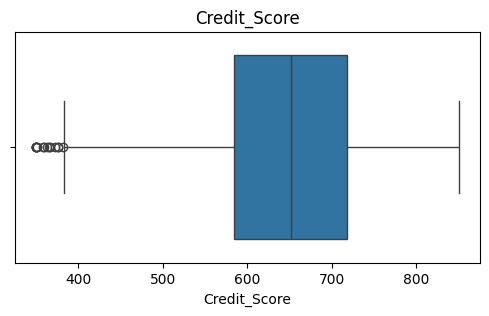

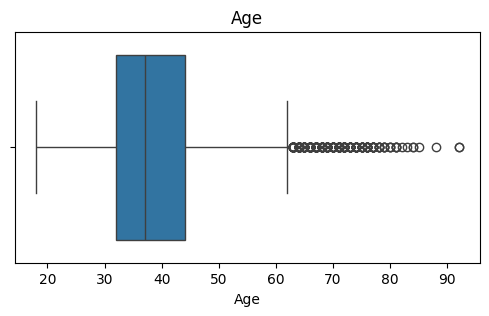

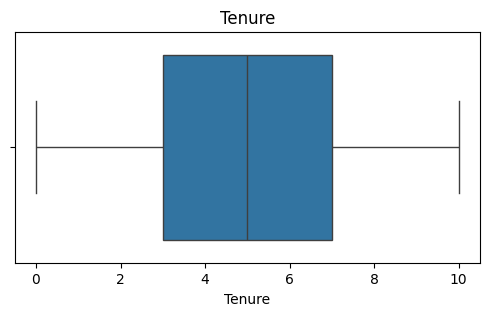

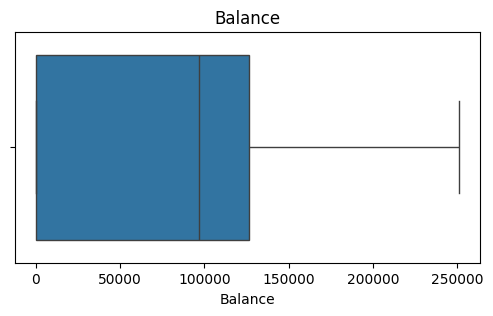

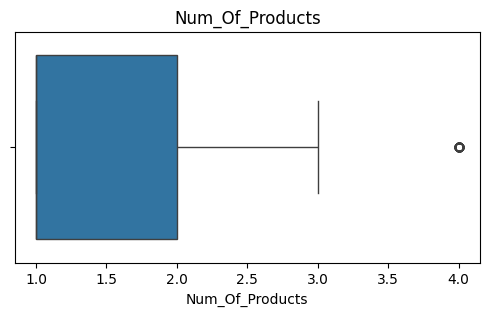

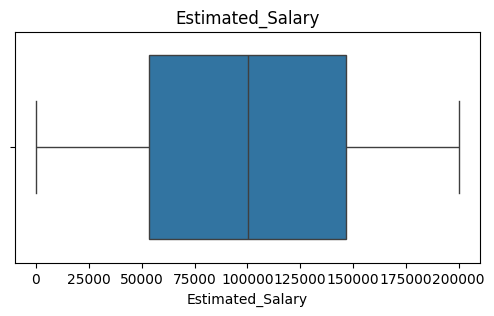

In [79]:
for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [82]:
df.to_csv('../data/interim/cleaned_day2.csv', index=False)

# Cleaning Summary

- Converted date columns to datetime format.
- Removed extra spaces from categorical variables.
- Removed duplicate records.
- Imputed missing values using mode and mean.
- Identified potential outliers using boxplots and IQR method.
- Saved cleaned dataset for further analysis.